# Lab: Multiple Linear Regression with scikit-learn

In this lab, you'll learn how to fit a **Multiple Linear Regression** model using scikit-learn — extending the same three-step pattern you saw in the Simple Linear Regression lab:

1. **Instantiate** the model
2. **Fit** the model to data
3. **Inspect** the learned parameters

The key difference from simple linear regression is that we now use **multiple features** to predict the target, allowing us to capture the combined effect of several variables.

We'll continue using the *Advertising* dataset, which records TV, Radio, and Newspaper advertising spend (in thousands of dollars) and sales (in thousands of units) across 200 markets.

---

## 1. Setup

Let's import the libraries we need and configure the plotting style.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# Plotting configuration
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

## 2. Load & Inspect the Data

In [4]:
# Load the dataset
sales_df = pd.read_csv("../data/raw/advertising.csv")

# Preview the first 5 rows
sales_df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
# General information about the dataset
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## 3. Prepare the Data

This time we'll use **all three advertising channels** as features and lowercase the column names for convenience.

In [6]:
# Drop the unnecessary index column and lowercase column names
sales_df.columns = [col.lower() for col in sales_df.columns]

sales_df.head()

,tv,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## 4. Visualize the Relationships

Before fitting a model, let's look at the pairwise relationships between each feature and the target. This gives us intuition for which features might be most useful.

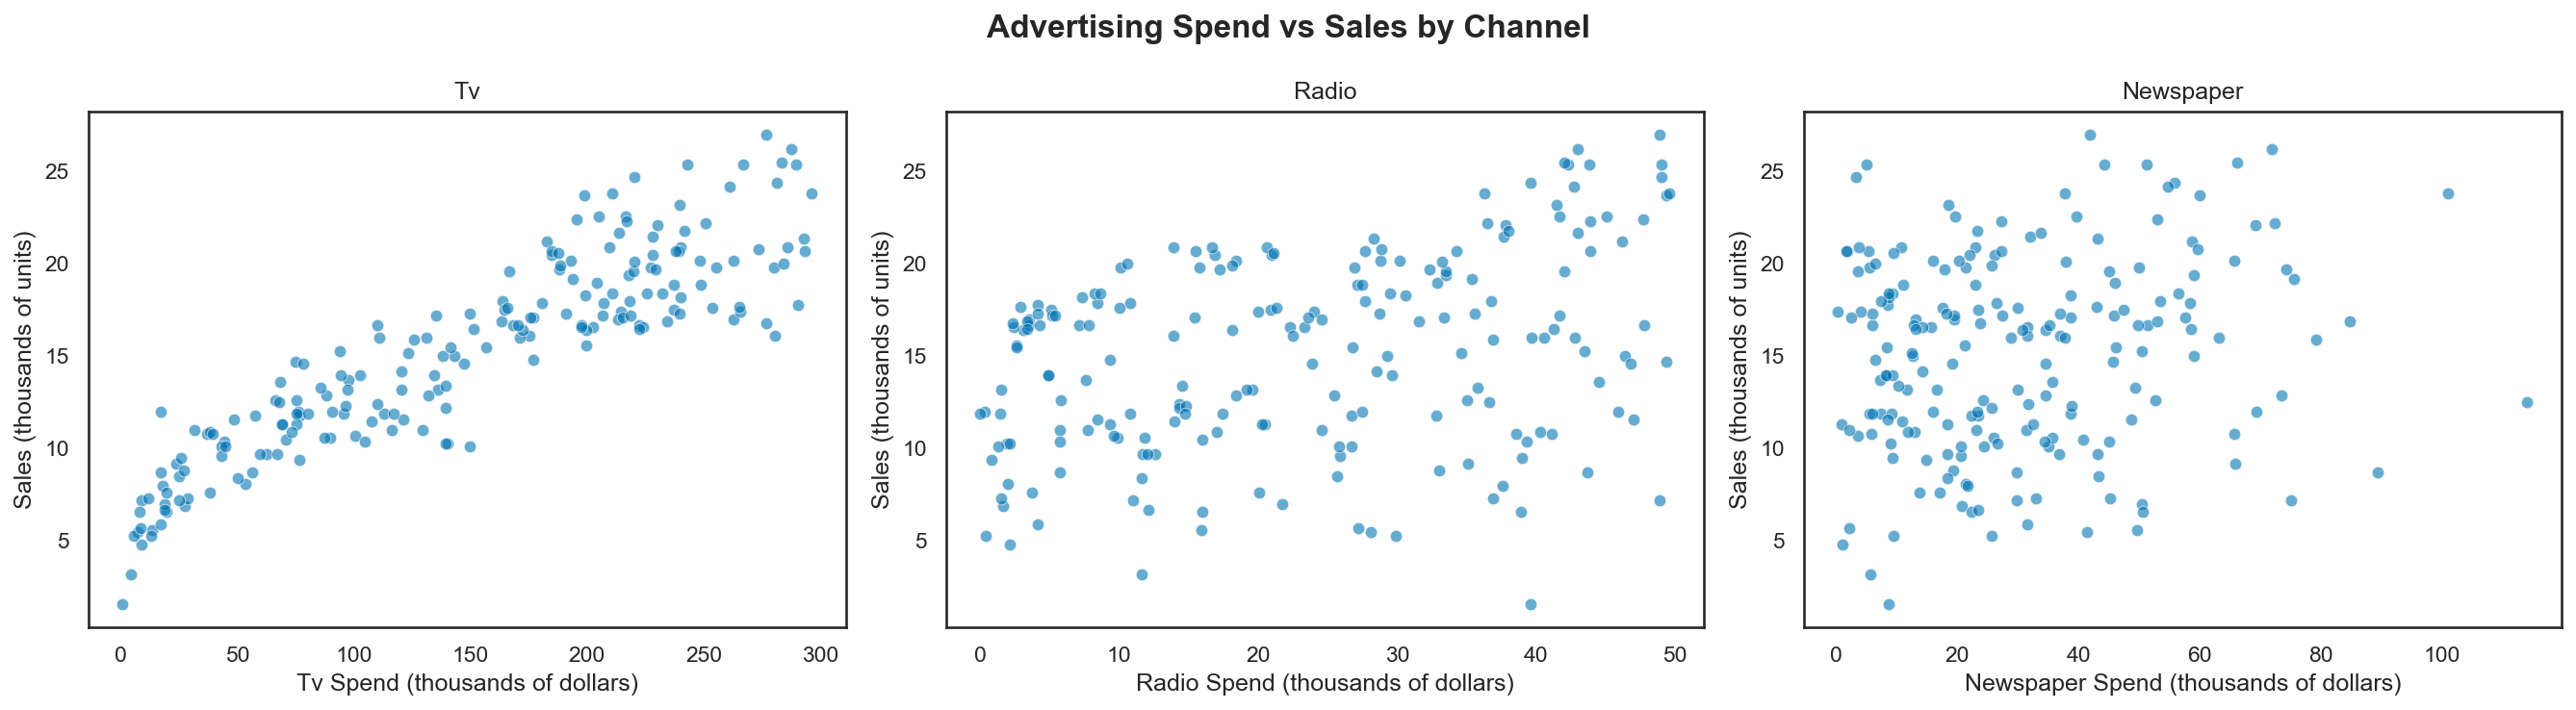

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Advertising Spend vs Sales by Channel", fontsize=16, fontweight="bold")

for ax, feature in zip(axes, ["tv", "radio", "newspaper"]):
    sns.scatterplot(data=sales_df, x=feature, y="sales", alpha=0.6, ax=ax)
    ax.set_xlabel(f"{feature.capitalize()} Spend (thousands of dollars)")
    ax.set_ylabel("Sales (thousands of units)")
    ax.set_title(feature.capitalize())

plt.tight_layout()
plt.show()

**Observations:**
- **TV** has the clearest positive linear relationship with sales.
- **Radio** also shows a positive relationship, though with more spread.
- **Newspaper** shows a much weaker relationship — the model will tell us exactly how much each channel contributes once we fit it.

---

## 5. Fit the Model with scikit-learn

The same three-step sklearn pattern applies here, just with a multi-column feature matrix `X`.

In [8]:
# Define the feature matrix (all three advertising channels) and the target
X = sales_df[["tv", "radio", "newspaper"]]
y = sales_df["sales"]

# Step 1: Instantiate the model
model = LinearRegression()

# Step 2: Fit the model to the full dataset
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 6. Inspect the Learned Parameters

With multiple features, `model.coef_` now returns **one coefficient per feature** — each representing the independent effect of that feature on the target, holding all others constant.

In [9]:
print(f"Intercept (β₀): {model.intercept_:.4f}")
print()

for feature, coef in zip(X.columns, model.coef_):
    print(f"Coefficient for '{feature}': {coef:.4f}")

print()
print("Fitted equation:")
equation = f"Sales = {model.intercept_:.4f}"
for feature, coef in zip(X.columns, model.coef_):
    equation += f" + {coef:.4f} × {feature}"
print(f"  {equation}")

Intercept (β₀): 4.6251

Coefficient for 'tv': 0.0544
Coefficient for 'radio': 0.1070
Coefficient for 'newspaper': 0.0003

Fitted equation:
  Sales = 4.6251 + 0.0544 × tv + 0.1070 × radio + 0.0003 × newspaper


## 7. Interpret the Coefficients

Each coefficient tells us the expected change in sales for a $1,000 increase in that channel's spend, **holding all other channels constant**.

In [10]:
print("Interpretation of coefficients:")
print()
for feature, coef in zip(X.columns, model.coef_):
    direction = "increase" if coef > 0 else "decrease"
    print(
        f"  {feature.capitalize()}: for every additional $1,000 spent, "
        f"sales {direction} by ~{abs(coef * 1000):.0f} units "
        f"(holding other channels constant)."
    )

Interpretation of coefficients:

  Tv: for every additional $1,000 spent, sales increase by ~54 units (holding other channels constant).
  Radio: for every additional $1,000 spent, sales increase by ~107 units (holding other channels constant).
  Newspaper: for every additional $1,000 spent, sales increase by ~0 units (holding other channels constant).


## 8. Make Predictions

Once the model is fitted, we can use `model.predict()` to generate predictions for new inputs. Let's try a few hypothetical advertising budgets.

In [11]:
# Hypothetical budgets: [TV, Radio, Newspaper] (in thousands of dollars)
new_budgets = pd.DataFrame({
    "tv":        [100, 200, 50],
    "radio":     [20,  30,  5],
    "newspaper": [10,  50,  2]
})

predictions = model.predict(new_budgets)

new_budgets["predicted_sales"] = predictions
print(new_budgets.to_string(index=False))

 tv  radio  newspaper  predicted_sales
100     20         10        12.213083
200     30         50        18.741100
 50      5          2         7.883091


## 9. Summary

In this lab you extended the sklearn `LinearRegression` pattern to multiple features:

| Step | Code | What it does |
|------|------|--------------|
| Instantiate | `model = LinearRegression()` | Creates the model object |
| Fit | `model.fit(X, y)` | Finds the best-fit hyperplane through the data |
| Inspect | `model.intercept_`, `model.coef_` | Reads the intercept and **one coefficient per feature** |
| Predict | `model.predict(X_new)` | Generates predictions for new inputs |

**Key conceptual difference from simple linear regression:**
- Simple LR: one feature → one coefficient, fitting a *line*.
- Multiple LR: many features → one coefficient *per feature*, fitting a *hyperplane*.
- Each coefficient represents the effect of its feature **holding all other features constant**.

---

**Next:** [Logistic Regression Theory](./08_logistic_regression_theory.md)